## 1. Install & Import Library

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch

from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


In [27]:
MODEL_NAME = "ProsusAI/finbert"   # ganti ke "bert-base-uncased" kalau mau pakai BERT biasa
MAX_LEN = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


In [28]:
df = pd.read_csv('all-data.csv', encoding='latin-1', header=None, names=['sentiment', 'text'])
df['text'] = df['text'].str.strip()
df.head()


,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [29]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
df.head()


{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


,sentiment,text,label
0,neutral,"According to Gran , the company has no plans t...",1
1,neutral,Technopolis plans to develop in stages an area...,1
2,negative,The international electronic industry company ...,0
3,positive,With the new production plant the company woul...,2
4,positive,According to the company 's updated strategy f...,2


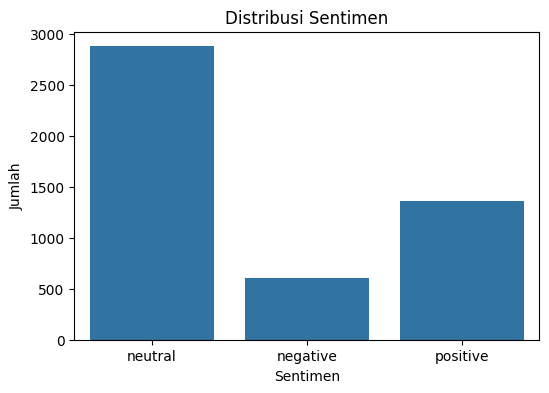

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()


## 4. Split Data (80-20) + Validation Split

In [31]:
X = df['text'].astype(str).to_list()
y = df['label'].to_numpy(dtype=int)

# Split 80-20 untuk train vs test (holdout final, sama seperti pipeline TextCNN)
x_train_full, x_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Dari bagian train, sisihkan validation_split=0.2 untuk monitoring selama training
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

In [32]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict


{0: np.float64(2.6770293609671847),
 1: np.float64(0.5609844372059356),
 2: np.float64(1.1850152905198776)}

## 5. Dataset & Tokenisasi

In [33]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = SentimentDataset(x_train, y_train, tokenizer, MAX_LEN)
val_dataset = SentimentDataset(x_val, y_val, tokenizer, MAX_LEN)
test_dataset = SentimentDataset(x_test, y_test, tokenizer, MAX_LEN)


## 6. Load Model + Weighted Trainer

`WeightedTrainer` dibuat supaya `class_weight_dict` yang sudah dihitung benar-benar dipakai saat menghitung loss (mengatasi masalah class imbalance, sama seperti fix di versi TextCNN sebelumnya).

In [34]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True  # classifier head lama (kalau ada) diganti head baru sesuai 3 kelas kita
)


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


Loading weights: 100%|██████████| 201/201 [00:00<?, ?it/s]


In [35]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}


## 7. Training Arguments & Fine-tuning

Learning rate kecil (2e-5) dan epoch sedikit (5) sengaja dipakai — ini praktik standar fine-tuning BERT, karena model sudah punya representasi bahasa yang kuat, jadi tidak perlu training lama seperti TextCNN dari nol. `load_best_model_at_end=True` otomatis mengembalikan checkpoint dengan val_loss terbaik, mirip fungsi EarlyStopping+restore_best_weights sebelumnya.

In [36]:
training_args = TrainingArguments(
    output_dir='./bert_sentiment_ckpt',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=1,
    report_to='none',
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=1.1.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=1.1.0'`

## 8. Evaluasi di Test Set (Holdout 20%)

In [ ]:
test_results = trainer.evaluate(test_dataset)
print(test_results)


c:\Users\HP Victus\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.032249,0.389711,5,0.867010,0.867955


{'eval_loss': 0.3897111117839813, 'eval_accuracy': 0.8670103092783505, 'eval_f1': 0.8679549219749645}


In [ ]:
pred_output = trainer.predict(test_dataset)
y_pred_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=-1).numpy()
y_pred_class = np.argmax(y_pred_proba, axis=-1)

print(classification_report(y_test, y_pred_class, target_names=le.classes_))


c:\Users\HP Victus\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.79      0.92      0.85       121
     neutral       0.92      0.86      0.89       576
    positive       0.80      0.85      0.83       273

    accuracy                           0.87       970
   macro avg       0.84      0.88      0.86       970
weighted avg       0.87      0.87      0.87       970



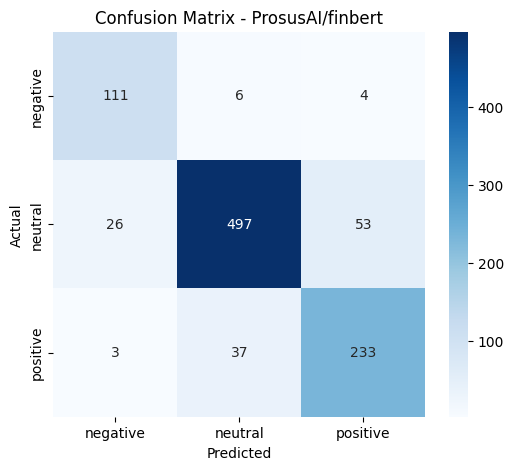

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
plt.show()


## 9. Plot Training History

Berbeda dari Keras `history.history`, HF `Trainer` menyimpan log per-epoch di `trainer.state.log_history`. Grafik ini menunjukkan train loss vs validation loss (indikator overfitting), dan validation accuracy per epoch.

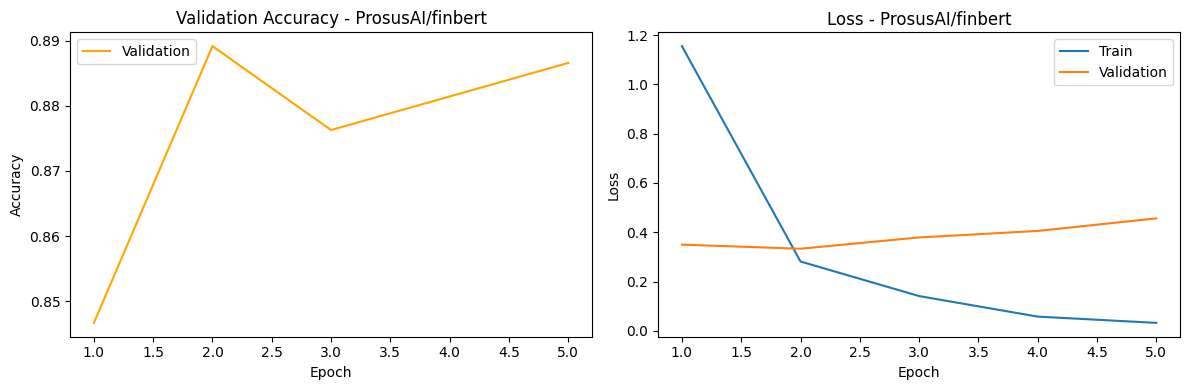

In [ ]:
log_history = trainer.state.log_history

train_loss = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_acc = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]

# Align lengths before plotting to avoid dimension mismatch errors
n = min(len(train_loss), len(eval_loss))
if n == 0:
    print('Not enough log history to plot training curves.')
else:
    epochs_range = range(1, n + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Use available validation accuracy values or fill with NaN if missing
    eval_acc_plot = eval_acc[:n] if len(eval_acc) >= n else ([np.nan] * n)
    axes[0].plot(epochs_range, eval_acc_plot, label='Validation', color='orange')
    axes[0].set_title(f'Validation Accuracy - {MODEL_NAME}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(epochs_range, train_loss[:n], label='Train')
    axes[1].plot(epochs_range, eval_loss[:n], label='Validation')
    axes[1].set_title(f'Loss - {MODEL_NAME}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 10. ROC Curve per Kelas

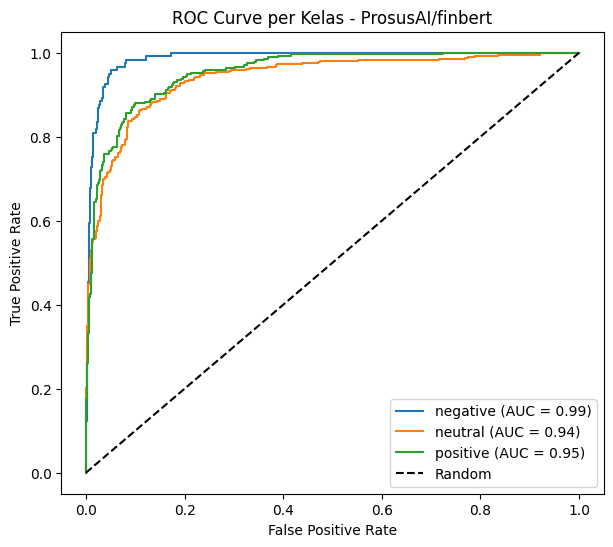

In [ ]:
n_classes = len(le.classes_)
class_names = le.classes_
y_true_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve per Kelas - {MODEL_NAME}')
plt.legend()
plt.show()


In [ ]:
import os

SAVE_DIR = "./finbert_sentiment_final"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cara resmi & disarankan untuk model + tokenizer HuggingFace
trainer.save_model(SAVE_DIR)        # simpan bobot model + config
tokenizer.save_pretrained(SAVE_DIR) # simpan tokenizer

print(f"Model & tokenizer tersimpan di: {SAVE_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.70it/s]

Model & tokenizer tersimpan di: ./finbert_sentiment_final


In [ ]:
import joblib

# Joblib dipakai untuk artefak ringan non-model (LabelEncoder, mapping label, class weight)
# supaya konsisten dengan pipeline sklearn (LabelEncoder) yang kamu pakai di awal notebook.

artifacts = {
    "label_encoder": le,
    "label_mapping": dict(zip(le.classes_, le.transform(le.classes_))),
    "class_weight_dict": class_weight_dict,
    "model_name": MODEL_NAME,
    "max_len": MAX_LEN,
}

joblib.dump(artifacts, "sentiment_artifacts.joblib")
print("Artefak (LabelEncoder, dll) tersimpan di: sentiment_artifacts.joblib")

Artefak (LabelEncoder, dll) tersimpan di: sentiment_artifacts.joblib
